In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

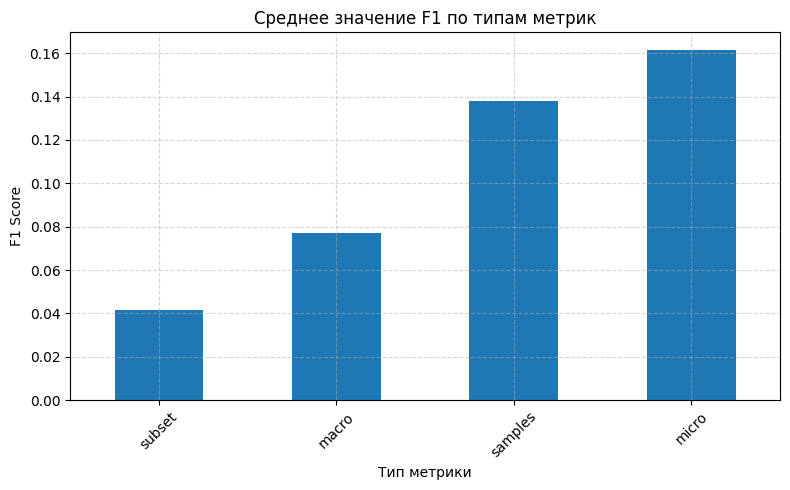

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Путь к директории с результатами
results_dir = '../tests/terraform/results'

# Сбор всех CSV-файлов
csv_files = [
    os.path.join(root, file)
    for root, _, files in os.walk(results_dir)
    for file in files if file.endswith('.csv')
]

# Объединение всех таблиц в одну
dataframes = []
for file in csv_files:
    try:
        df = pd.read_csv(file)
        dataframes.append(df)
    except Exception as e:
        print(f"Ошибка при чтении {file}: {e}")

if not dataframes:
    print("Не найдено ни одного CSV-файла.")
else:
    combined_df = pd.concat(dataframes, ignore_index=True)

    # Преобразуем столбец f1 к числовому виду
    combined_df['f1'] = pd.to_numeric(combined_df['f1'], errors='coerce')

    # Удалим строки без F1
    filtered_df = combined_df.dropna(subset=['f1'])

    # Группировка по типу метрики и построение графика
    plt.figure(figsize=(8, 5))
    filtered_df.groupby('metric')['f1'].mean().sort_values().plot(kind='bar')
    plt.title('Среднее значение F1 по типам метрик')
    plt.xlabel('Тип метрики')
    plt.ylabel('F1 Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


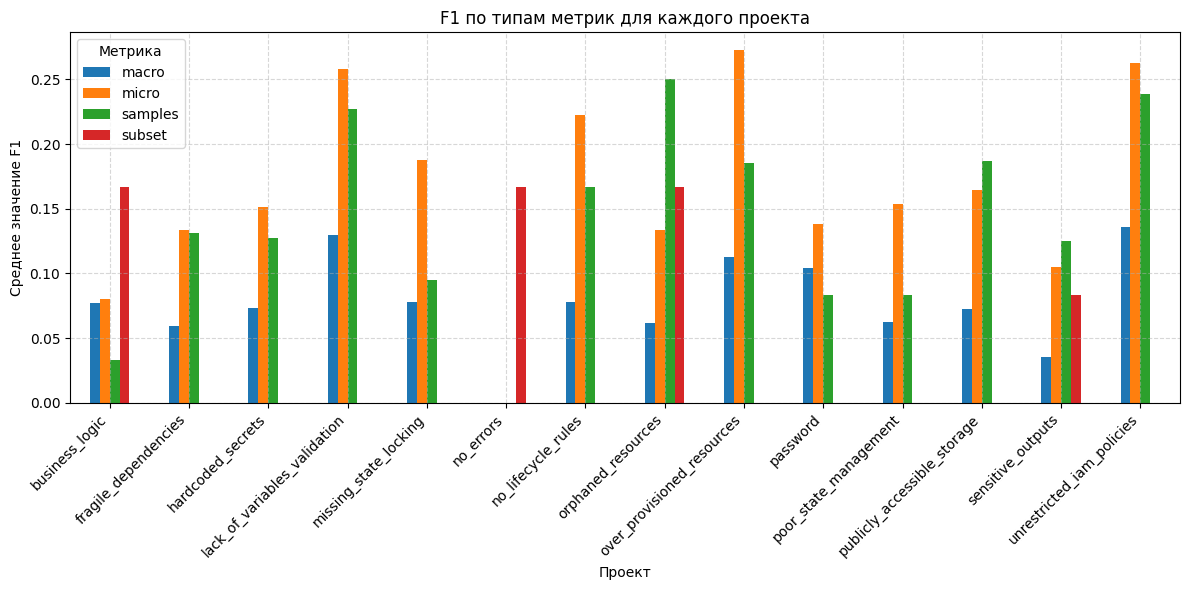

In [7]:
if {'project_name', 'metric', 'f1'}.issubset(filtered_df.columns):
    # Группировка: средние значения F1 по каждому проекту и типу метрики
    grouped = filtered_df.groupby(['project_name', 'metric'])['f1'].mean().unstack()

    # Построение составной гистограммы
    grouped.plot(kind='bar', figsize=(12, 6))
    plt.title('F1 по типам метрик для каждого проекта')
    plt.xlabel('Проект')
    plt.ylabel('Среднее значение F1')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Метрика')
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
else:
    print("Не хватает нужных столбцов для построения гистограммы.")

In [8]:
grouped

metric,macro,micro,samples,subset
project_name,,,,
business_logic,0.0769,0.0800,0.0333,0.1667
fragile_dependencies,0.0593,0.1333,0.1312,0.0000
hardcoded_secrets,0.0736,0.1515,0.1274,0.0000
lack_of_variables_validation,0.1296,0.2581,0.2267,0.0000
missing_state_locking,0.0778,0.1875,0.0952,0.0000
no_errors,0.0000,0.0000,0.0000,0.1667
no_lifecycle_rules,0.0778,0.2222,0.1667,0.0000
orphaned_resources,0.0614,0.1333,0.2500,0.1667
over_provisioned_resources,0.1125,0.2727,0.1852,0.0000
